# 17. False Detection Feature Overlap Analysis

Notebook ini digunakan untuk mengambil sampel citra yang salah diklasifikasikan, kemudian menganalisis posisinya pada ruang fitur dua dimensi. Secara bawaan, analisis menggunakan konfigurasi `FFT + CLIP` dengan model `XGBoost`, karena konfigurasi ini merupakan konfigurasi terbaik pada eksperimen utama.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

ARTIFACT_DIR = PROJECT_ROOT / "artifacts"
FIG_DIR = ARTIFACT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

TARGET_FEATURE_LABEL = "FFT + CLIP"
TARGET_MODEL = "XGBoost"
N_FALSE_POSITIVE = 3
N_FALSE_NEGATIVE = 3
N_NEIGHBORS = 10
RANDOM_STATE = 42

FEATURE_VECTOR_FILES = {
    "FFT only": ARTIFACT_DIR / "feature_vector_biggan_midjourney_multiclass_fft_only.csv",
    "CLIP only": ARTIFACT_DIR / "feature_vector_biggan_midjourney_multiclass_clip_only.csv",
    "IQA only": ARTIFACT_DIR / "feature_vector_biggan_midjourney_multiclass_iqa_only.csv",
    "FFT + CLIP": ARTIFACT_DIR / "feature_vector_biggan_midjourney_multiclass_fft_clip.csv",
    "IQA + FFT": ARTIFACT_DIR / "feature_vector_biggan_midjourney_multiclass_iqa_fft.csv",
    "IQA + CLIP": ARTIFACT_DIR / "feature_vector_biggan_midjourney_multiclass_iqa_clip.csv",
    "IQA + FFT + CLIP": ARTIFACT_DIR / "feature_vector_biggan_midjourney_multiclass_iqa_fft_clip.csv",
}

PREDICTION_FILES = {
    "FFT only": ARTIFACT_DIR / "predictions_classification_biggan_midjourney_multiclass_fft_only.csv",
    "CLIP only": ARTIFACT_DIR / "predictions_classification_biggan_midjourney_multiclass_clip_only.csv",
    "IQA only": ARTIFACT_DIR / "predictions_classification_biggan_midjourney_multiclass_iqa_only.csv",
    "FFT + CLIP": ARTIFACT_DIR / "predictions_classification_biggan_midjourney_multiclass_fft_clip.csv",
    "IQA + FFT": ARTIFACT_DIR / "predictions_classification_biggan_midjourney_multiclass_iqa_fft.csv",
    "IQA + CLIP": ARTIFACT_DIR / "predictions_classification_biggan_midjourney_multiclass_iqa_clip.csv",
    "IQA + FFT + CLIP": ARTIFACT_DIR / "predictions_classification_biggan_midjourney_multiclass_iqa_fft_clip.csv",
}

print("Project root:", PROJECT_ROOT)
print("Target feature set:", TARGET_FEATURE_LABEL)
print("Target model:", TARGET_MODEL)

Project root: /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold
Target feature set: FFT + CLIP
Target model: XGBoost


In [2]:
pred_path = PREDICTION_FILES[TARGET_FEATURE_LABEL]
feature_path = FEATURE_VECTOR_FILES[TARGET_FEATURE_LABEL]

preds_all = pd.read_csv(pred_path)
features = pd.read_csv(feature_path)

preds = preds_all[preds_all["model"] == TARGET_MODEL].copy()
preds["y_ai"] = preds["y_ai"].astype(int)
preds["pred_ai"] = preds["pred_ai"].astype(int)
preds["score_ai"] = preds["score_ai"].astype(float)
preds["label_text"] = np.where(preds["y_ai"] == 1, "AI", "Nature")
preds["pred_text"] = np.where(preds["pred_ai"] == 1, "AI", "Nature")
preds["error_type"] = "Correct"
preds.loc[(preds["y_ai"] == 0) & (preds["pred_ai"] == 1), "error_type"] = "False Positive"
preds.loc[(preds["y_ai"] == 1) & (preds["pred_ai"] == 0), "error_type"] = "False Negative"

false_positive = preds[preds["error_type"] == "False Positive"].sort_values("score_ai", ascending=False)
false_negative = preds[preds["error_type"] == "False Negative"].sort_values("score_ai", ascending=True)
sample_errors = pd.concat(
    [false_positive.head(N_FALSE_POSITIVE), false_negative.head(N_FALSE_NEGATIVE)],
    ignore_index=True,
)
sample_errors["sample_id"] = [f"E{i+1}" for i in range(len(sample_errors))]

display(preds["error_type"].value_counts())
display(sample_errors[["sample_id", "error_type", "path", "generator", "content_label", "label_text", "pred_text", "score_ai"]])

error_type
Correct           1571
False Negative      18
False Positive      11
Name: count, dtype: int64

,sample_id,error_type,path,generator,content_label,label_text,pred_text,score_ai
0,E1,False Positive,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,BigGAN,goldfish,Nature,AI,0.993803
1,E2,False Positive,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,MidJourney,tench,Nature,AI,0.989194
2,E3,False Positive,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,MidJourney,Chihuahua,Nature,AI,0.988435
3,E4,False Negative,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,MidJourney,Siamese_cat,AI,Nature,0.013129
4,E5,False Negative,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,MidJourney,Chesapeake_Bay_retriever,AI,Nature,0.022890
5,E6,False Negative,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,MidJourney,black_swan,AI,Nature,0.037997


In [3]:
FEATURE_PREFIXES = ("fft_", "clip_feat_")
FEATURE_NAMES = {"piqe", "brisque", "niqe"}
feature_cols = [
    col for col in features.columns
    if col.startswith(FEATURE_PREFIXES) or col in FEATURE_NAMES
]

if not feature_cols:
    raise ValueError("Tidak ada kolom fitur numerik yang ditemukan pada feature vector.")

non_numeric_cols = features[feature_cols].select_dtypes(exclude=[np.number]).columns.tolist()
if non_numeric_cols:
    raise ValueError(f"Kolom fitur non-numerik terdeteksi: {non_numeric_cols}")

print("Jumlah fitur untuk t-SNE:", len(feature_cols))

eval_df = preds.merge(features[["image_id", *feature_cols]], on="image_id", how="left")
if eval_df[feature_cols].isna().any().any():
    raise ValueError("Terdapat fitur kosong setelah prediksi digabungkan dengan feature vector.")

X = eval_df[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0.0)
X_scaled = StandardScaler().fit_transform(X)

perplexity = min(30, max(5, (len(eval_df) - 1) // 3))
tsne = TSNE(
    n_components=2,
    perplexity=perplexity,
    init="random",
    learning_rate="auto",
    random_state=RANDOM_STATE,
)
coords = tsne.fit_transform(X_scaled)
eval_df["tsne_1"] = coords[:, 0]
eval_df["tsne_2"] = coords[:, 1]

sample_errors = sample_errors.merge(eval_df[["image_id", "tsne_1", "tsne_2"]], on="image_id", how="left")
display(sample_errors[["sample_id", "error_type", "label_text", "pred_text", "score_ai", "tsne_1", "tsne_2"]])

Jumlah fitur untuk t-SNE: 68


,sample_id,error_type,label_text,pred_text,score_ai,tsne_1,tsne_2
0,E1,False Positive,Nature,AI,0.993803,-35.887634,-20.516066
1,E2,False Positive,Nature,AI,0.989194,-27.110535,-15.391588
2,E3,False Positive,Nature,AI,0.988435,-23.703581,21.910782
3,E4,False Negative,AI,Nature,0.013129,-19.834778,11.507289
4,E5,False Negative,AI,Nature,0.022890,-33.041283,27.817818
5,E6,False Negative,AI,Nature,0.037997,18.646303,14.381711


In [4]:
neighbor_model = NearestNeighbors(n_neighbors=min(N_NEIGHBORS + 1, len(eval_df)))
neighbor_model.fit(eval_df[["tsne_1", "tsne_2"]])

neighbor_rows = []
for _, err in sample_errors.iterrows():
    point = err[["tsne_1", "tsne_2"]].to_numpy(dtype=float).reshape(1, -1)
    distances, indices = neighbor_model.kneighbors(point)
    neighbors = eval_df.iloc[indices[0]].copy()
    neighbors["distance"] = distances[0]
    neighbors = neighbors[neighbors["image_id"] != err["image_id"]].head(N_NEIGHBORS)
    opposite = neighbors[neighbors["label_text"] != err["label_text"]]
    nearest_opposite_distance = np.nan if opposite.empty else opposite["distance"].min()
    neighbor_rows.append({
        "sample_id": err["sample_id"],
        "error_type": err["error_type"],
        "filename": Path(err["path"]).name,
        "label_text": err["label_text"],
        "pred_text": err["pred_text"],
        "score_ai": err["score_ai"],
        "tsne_1": err["tsne_1"],
        "tsne_2": err["tsne_2"],
        "opposite_label_neighbors": int((neighbors["label_text"] != err["label_text"]).sum()),
        "same_label_neighbors": int((neighbors["label_text"] == err["label_text"]).sum()),
        "nearest_opposite_distance": nearest_opposite_distance,
    })

neighbor_summary = pd.DataFrame(neighbor_rows)
sample_out = ARTIFACT_DIR / "false_detection_samples_17_fft_clip_xgboost.csv"
neighbor_out = ARTIFACT_DIR / "false_detection_tsne_neighbor_summary_17_fft_clip_xgboost.csv"
sample_errors.to_csv(sample_out, index=False)
neighbor_summary.to_csv(neighbor_out, index=False)

display(neighbor_summary)
print("Saved:", sample_out)
print("Saved:", neighbor_out)

/home/nanda/miniconda3/envs/ai/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(
/home/nanda/miniconda3/envs/ai/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(
/home/nanda/miniconda3/envs/ai/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(
/home/nanda/miniconda3/envs/ai/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(
/home/nanda/miniconda3/envs/ai/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but Near

,sample_id,error_type,filename,label_text,pred_text,score_ai,tsne_1,tsne_2,opposite_label_neighbors,same_label_neighbors,nearest_opposite_distance
0,E1,False Positive,n01443537_4702.JPEG,Nature,AI,0.993803,-35.887634,-20.516066,1,9,1.131222
1,E2,False Positive,n01440764_9811.JPEG,Nature,AI,0.989194,-27.110535,-15.391588,2,8,1.987850
2,E3,False Positive,n02085620_10270.JPEG,Nature,AI,0.988435,-23.703581,21.910782,7,3,1.456550
3,E4,False Negative,284_midjourney_56.png,AI,Nature,0.013129,-19.834778,11.507289,6,4,0.794616
4,E5,False Negative,209_midjourney_74.png,AI,Nature,0.022890,-33.041283,27.817818,2,8,2.662124
5,E6,False Negative,100_midjourney_174.png,AI,Nature,0.037997,18.646303,14.381711,2,8,1.103490


Saved: /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/artifacts/false_detection_samples_17_fft_clip_xgboost.csv
Saved: /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/artifacts/false_detection_tsne_neighbor_summary_17_fft_clip_xgboost.csv


Saved: /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/artifacts/figures/17_false_detection_tsne_fft_clip_xgboost.png


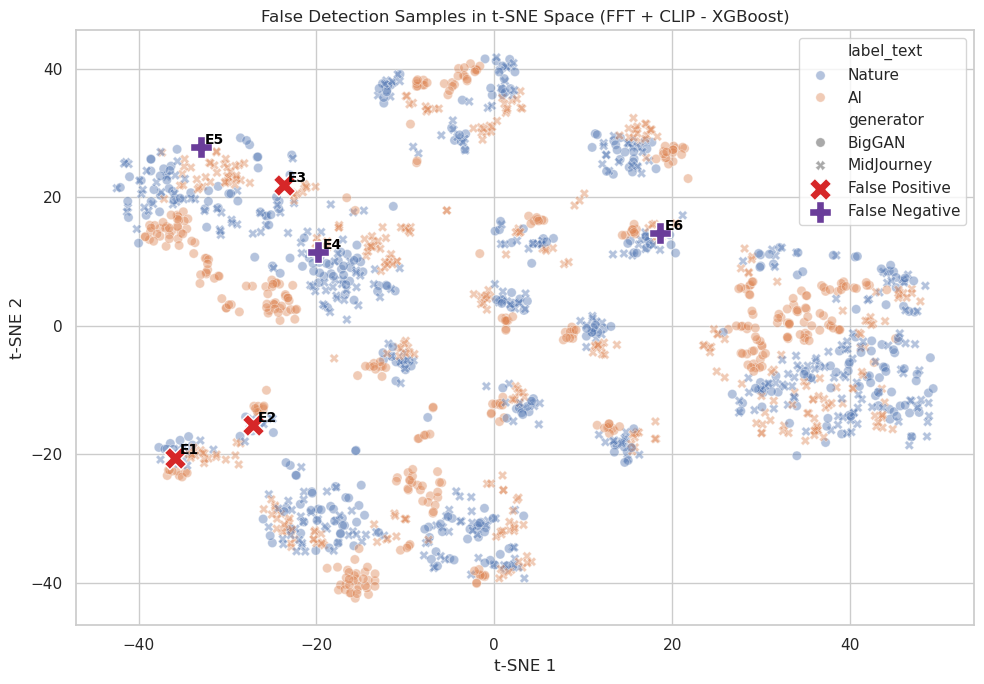

In [5]:
fig, ax = plt.subplots(figsize=(10, 7))
sns.scatterplot(
    data=eval_df,
    x="tsne_1",
    y="tsne_2",
    hue="label_text",
    style="generator",
    alpha=0.42,
    s=45,
    ax=ax,
)

error_styles = {
    "False Positive": {"marker": "X", "color": "#d62728", "label": "False Positive"},
    "False Negative": {"marker": "P", "color": "#6a3d9a", "label": "False Negative"},
}
for error_type, style in error_styles.items():
    sub = sample_errors[sample_errors["error_type"] == error_type]
    if sub.empty:
        continue
    ax.scatter(
        sub["tsne_1"],
        sub["tsne_2"],
        marker=style["marker"],
        c=style["color"],
        edgecolors="white",
        linewidths=1.0,
        s=260,
        label=style["label"],
        zorder=5,
    )

for _, row in sample_errors.iterrows():
    ax.text(
        row["tsne_1"] + 0.5,
        row["tsne_2"] + 0.5,
        row["sample_id"],
        fontsize=10,
        weight="bold",
        color="black",
        zorder=6,
    )

ax.set_title(f"False Detection Samples in t-SNE Space ({TARGET_FEATURE_LABEL} - {TARGET_MODEL})")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.legend(loc="best", frameon=True)
fig.tight_layout()

scatter_out = FIG_DIR / "17_false_detection_tsne_fft_clip_xgboost.png"
fig.savefig(scatter_out, dpi=200, bbox_inches="tight")
print("Saved:", scatter_out)
plt.show()


Saved: /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/artifacts/figures/17_false_detection_examples_fft_clip_xgboost.png


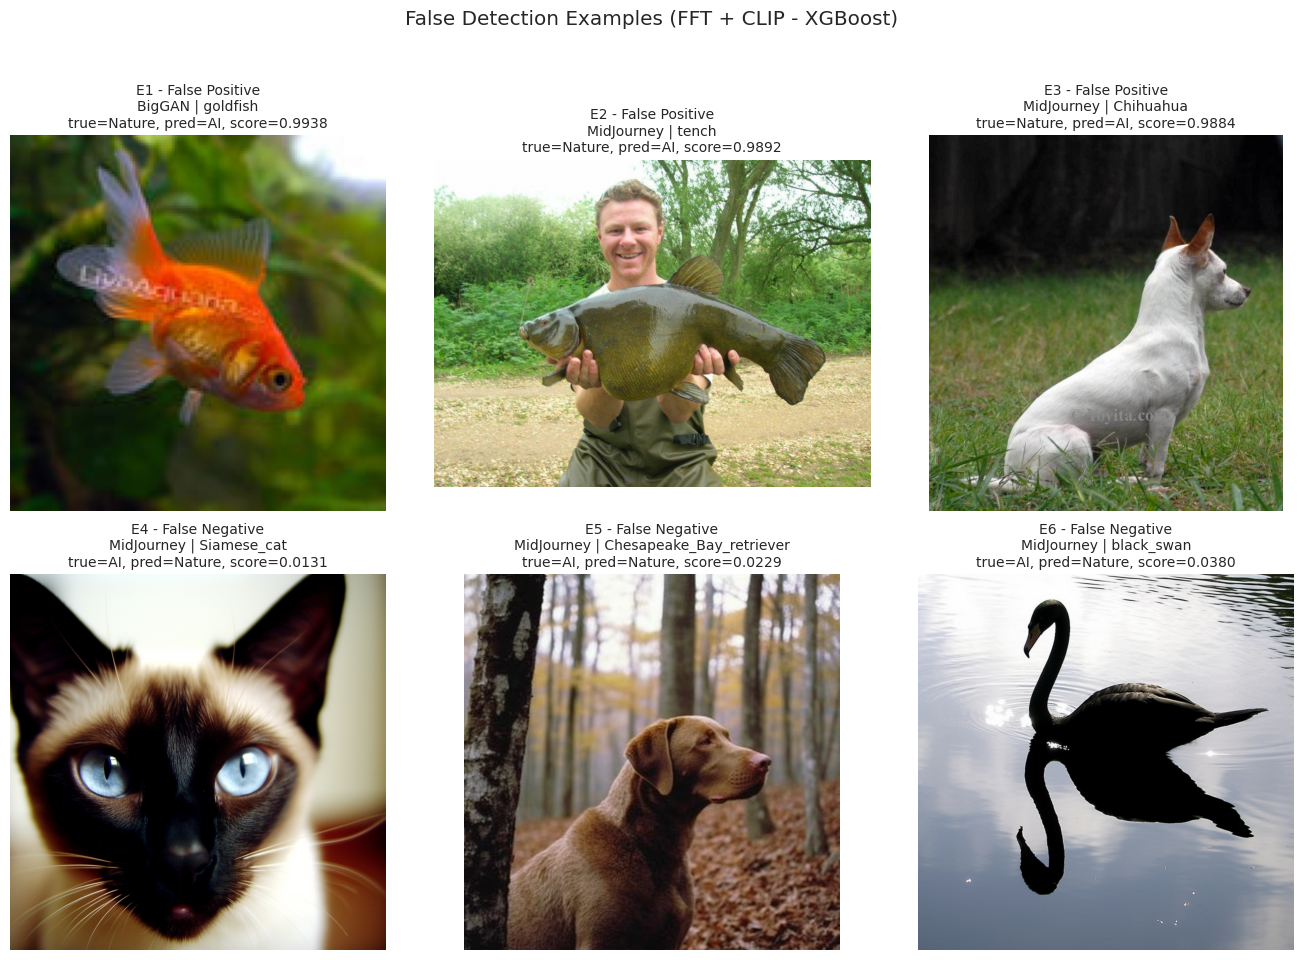

In [6]:
n = len(sample_errors)
cols = min(3, max(1, n))
rows = int(np.ceil(n / cols))
fig, axes = plt.subplots(rows, cols, figsize=(4.6 * cols, 4.7 * rows))
axes = np.array(axes).reshape(-1)

for ax, (_, row) in zip(axes, sample_errors.iterrows()):
    image = Image.open(row["path"]).convert("RGB")
    ax.imshow(image)
    ax.axis("off")
    ax.set_title(
        f"{row['sample_id']} - {row['error_type']}\n"
        f"{row['generator']} | {row['content_label']}\n"
        f"true={row['label_text']}, pred={row['pred_text']}, score={row['score_ai']:.4f}",
        fontsize=10,
    )

for ax in axes[n:]:
    ax.axis("off")

fig.suptitle(f"False Detection Examples ({TARGET_FEATURE_LABEL} - {TARGET_MODEL})", y=1.02)
fig.tight_layout()

examples_out = FIG_DIR / "17_false_detection_examples_fft_clip_xgboost.png"
fig.savefig(examples_out, dpi=200, bbox_inches="tight")
print("Saved:", examples_out)
plt.show()

## Catatan Analisis

Gunakan file `false_detection_tsne_neighbor_summary_17_fft_clip_xgboost.csv` untuk melihat apakah sampel salah klasifikasi memiliki banyak tetangga dari kelas lawan pada ruang t-SNE. Jika nilai `opposite_label_neighbors` tinggi atau `nearest_opposite_distance` kecil, maka sampel tersebut berada dekat dengan kelas lawan pada representasi fitur dua dimensi. Kondisi tersebut dapat digunakan sebagai indikasi kualitatif bahwa kesalahan model berkaitan dengan kecenderungan overlap pada ruang fitur.